# Amazon Data Analysis & Review Score Prediction

## Milestone 2 Spark Setup

In [1]:
import pyspark
from pyspark.sql import SparkSession
from pyspark import StorageLevel
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib created a temporary cache directory at /scratch/bguo3/job_47480404/matplotlib-gbsd8ak6 because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# Initializing our spark
"""
Formula == 
Executor instances = Total Cores - 1
Executor memory = (Total Memory - Driver Memory) / Executor Instances

Milestone 2
Executor instances = 32 − 1 = 31
Executor memory = (128 − 2) / 31 ≈ 4.06GB → 4GB per executor

Milestones 3 Update:
We had to update our Spark set-up beecause of memory leak and large overhead issues
We've run combinations of 8 cores X 8GB, 8 core X 16GB, 8 core X 24GB
This set-up depends on the resources at hand
"""


# Milestone 2 setup
# spark= (
#     SparkSession.builder
#     .appName('amazon_set')
#     .config('spark.driver.memory', '2g')
#     .config('spark.executor.instances', '31')
#     .config('spark.executor.memory', '4g')
#     .config('spark.executor.cores', '1')
#     .getOrCreate()
# )

# Milestone 3 latest set up
# spark = (
#     SparkSession.builder
#     .appName('amazon_set')
#     .config('spark.driver.memory', '4g')
#     .config('spark.executor.instances', '7')
#     .config('spark.executor.memory', '24g')
#     .config('spark.executor.cores', '1')
#     .getOrCreate()
# )

# Milestone 4 latest set up (If allocated for 118 GB memory per node)
# spark = (
#     SparkSession.builder
#     .appName('amazon_set')
#     .config('spark.driver.memory', '10g')
#     .config('spark.executor.instances', '7')
#     .config('spark.executor.memory', '12g')
#     .config('spark.executor.cores', '1')
#     .getOrCreate()
# )

# Milestone 4 latest set up (If allocated for 201 GB memory per node) (1 core per executor)
# spark = (
#     SparkSession.builder
#     .appName('amazon_set')
#     .config('spark.driver.memory', '10g')
#     .config('spark.executor.instances', '8')
#     .config('spark.executor.memory', '19g')
#     .config('spark.executor.cores', '1')
#     .getOrCreate()
# )

# Milestone 4 latest set up (If allocated for 201 GB memory per node) (2 cores per executor)
spark = (
    SparkSession.builder
    .appName("amazon_set")
    .config("spark.driver.memory", "10g")
    .config("spark.driver.cores", "1")
    .config("spark.executor.instances", "4")
    .config("spark.executor.cores", "2")
    .config("spark.executor.memory", "38g")
    .config("spark.sql.shuffle.partitions", "32")
    .config("spark.default.parallelism", "32")
    .config("spark.driver.maxResultSize", "4g")
    .getOrCreate()
)

In [3]:
import requests
import pandas as pd # RECALL we're going to use spark not pandas

# Get the active Spark Context and URL
sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"
print(f'Spark UI URL: {sc.uiWebUrl}') 

# Fetch the executor data from the API
response = requests.get(url)
executors = response.json()

# Format into a readable DataFrame
df = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
df['maxMemory_GB'] = (df['maxMemory'] / (1024**3)).round(2)
df

Spark UI URL: http://exp-2-20.expanse.sdsc.edu:4040


,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,9,6253707264,0,True,5.82


### Helper Functions

In [4]:
def row_memory_count(df):
    """
    Estimate row count and memory footprint of a Spark DataFrame.

    Args:
        df: Spark DataFrame to analyze

    Prints:
        - Total number of rows in the DataFrame
        - Estimated total memory usage in GB
    """

    # How many df rows do we have?
    row_counts = df.count()
    print(f"Total row counts: {row_counts} rows")
    
    # How much does df occupy in memory?
    sample_fraction = 0.001
    sample_size_in_bytes = (
        df
        .sample(fraction=sample_fraction)
        .toPandas()
        .memory_usage(deep=True)
        .sum()
    ) 
    total_size_in_gb = sample_size_in_bytes / (sample_fraction * (1024**3))
    print(f"Total estimated size: {total_size_in_gb:.2f} GB")

def plot_bar_chart(df, groupby_col, x_label, title, has_hue=True):
    """
    Plot a horizontal bar chart of the top N categories for a Spark DataFrame column.

    Args:
        df: Spark DataFrame
        groupby_col: Column name (string) to group by
        x_label: Label for the x-axis
        title: Plot title

    Notes:
        - Counts are annotated in millions (M) by default
    """
    
    # --- Data ---
    dist_pd = (
        df
        # Groupby + Agg(count) + Sort
        .groupBy(groupby_col)
        .count()
        .orderBy(F.desc('count'))
        .toPandas()
        .loc[lambda temp_df: temp_df[groupby_col].notna(), :]
        .assign(**{
            groupby_col: lambda df: df[groupby_col].astype('category')
        })
        .sort_values(by='count', ascending=False)
    )
    
    # --- Plot ---
    fig, ax = plt.subplots(figsize=(15, 6))
    sns.barplot(
        data=dist_pd,
        x='count',
        y=groupby_col,
        hue=groupby_col if has_hue else None,
        legend=False,
        palette='Blues_r' if has_hue else None,
        edgecolor='white',
        ax=ax,
        order=dist_pd[groupby_col].tolist(),
        hue_order=dist_pd[groupby_col].tolist()
    )
    # Edit text on categories
    for bar in ax.patches:
        w = bar.get_width()
        ax.text(
            w + 50_000, bar.get_y() + bar.get_height() / 2,
            f'{w/1_000_000:.2f}M',
            va='center', ha='left', fontsize=9, color='#333'
        )
    # Annotation
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_title(
        title, 
        fontsize=14, 
        fontweight='bold', 
        pad=15
    )
    plt.show()

def plot_histogram(df, column, x_label, title, bins=50, kde=False):
    """
    Plot a histogram for a numerical column from a Spark DataFrame.

    Args:
        df: Spark DataFrame
        column: column name (string)
        bins: number of bins
        x_label: label for x-axis
        title: plot title
    """
    
    # --- Data ---
    dist_pd = (
        df
        .select(column)
        # Use 1% sample
        .sample(fraction=0.01, seed=42)
        .toPandas()
    )

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.histplot(
        dist_pd[column], 
        bins=bins, 
        kde=kde, 
        color='skyblue', 
        edgecolor='white', 
        ax=ax
    )
    ax.set_xlabel(
        column, 
        fontsize=11
    )
    ax.set_title(
        title, 
        fontsize=14, 
        fontweight='bold'
    )
    plt.show()

def plot_boxplot(df, column, x_label, title):
    """
    Plot a box plot for a numerical column from a Spark DataFrame.

    Args:
        df: Spark DataFrame
        column: column name (string) to plot
        x_label: label for the x-axis (optional)
        title: plot title (optional)
        sample_fraction: fraction of rows to sample (default 0.01 = 1%)
    """
    
    # --- Data ---
    dist_pd = (
        df
        .select(column)
        # Use 1% sample
        .sample(fraction=0.01, seed=42)
        .toPandas()
    )

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.boxplot(
        y=dist_pd[column], 
        color='lightblue', 
        ax=ax
    )
    ax.set_ylabel(
        x_label, 
        fontsize=11
    )
    ax.set_title(
        title, 
        fontsize=14, 
        fontweight='bold'
    )
    plt.show()

## Milestone 2 Data Collection

In [5]:
import kagglehub
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    StringType, IntegerType,
    DateType
)

# Download dataset (cached by kagglehub)
base_dir = kagglehub.dataset_download('cynthiarempel/amazon-us-customer-reviews-dataset')
print('Downloaded to:', base_dir)

# Schema (recommended)
schema = StructType([
    StructField('marketplace', StringType(), True),
    StructField('customer_id', StringType(), True),
    StructField('review_id', StringType(), True),
    StructField('product_id', StringType(), True),
    StructField('product_parent', StringType(), True),
    StructField('product_title', StringType(), True),
    StructField('product_category', StringType(), True),
    StructField('star_rating', IntegerType(), True),
    StructField('helpful_votes', IntegerType(), True),
    StructField('total_votes', IntegerType(), True),
    StructField('vine', StringType(), True),
    StructField('verified_purchase', StringType(), True),
    StructField('review_headline', StringType(), True),
    StructField('review_body', StringType(), True),
    StructField('review_date', DateType(), True),
])

pattern = f'file:{base_dir}/amazon_reviews_us_*_v*.tsv'

reviews_df = (
    spark.read
        .option('header', 'true')
        .option('sep', '\t')
        .schema(schema)
        .csv(pattern)
        .withColumn('source_file', F.input_file_name())
        .withColumn('category', F.regexp_extract('source_file', r'amazon_reviews_us_([^/]+?)_v', 1))
        .filter(F.col('category') != 'multilingual')
        .drop('source_file')
)

Downloaded to: /home/bguo3/.cache/kagglehub/datasets/cynthiarempel/amazon-us-customer-reviews-dataset/versions/9


In [6]:
# Check the Spark details
print('master:', spark.sparkContext.master)
print('partitions:', reviews_df.rdd.getNumPartitions())

master: local[*]
partitions: 384


**Observations**: 
- We decided not cache the whole df yet because with 40GB and limited temporary storage, we had an error crash on Expanse.
- When caching the SparkSQL Dataframe, doing some tasks that involve occupying some space in memory evicted the cached memory and we had memory spills in storage. Unfortunately the temp storage also spills and crashes the jupyter kernel.
- Using SLURM, we maybe able to allocate more than 1 node, so hopefully that might helps, or caching the whole df might not even be a good idea from the start.

MILESTONE 3 NOTE:
We have to update our SDSC set-up

## Milestone 2 Exploratory Data Analysis

### Overall Inspection

In [7]:
# We want to check if the df is successfully loaded

reviews_df.select('category', 'star_rating', 'product_id').show(10, truncate=False)

+--------+-----------+----------+
|category|star_rating|product_id|
+--------+-----------+----------+
|Apparel |4          |B01KL6O72Y|
|Apparel |5          |B01ID3ZS5W|
|Apparel |5          |B01I497BGY|
|Apparel |5          |B01HDXFZK6|
|Apparel |5          |B01G6MBEBY|
|Apparel |5          |B01FWRXN0Y|
|Apparel |5          |B01EXNH1HE|
|Apparel |4          |B01E7OL09O|
|Apparel |5          |B01DXHX81O|
|Apparel |3          |B01DDULIJK|
+--------+-----------+----------+
only showing top 10 rows



In [8]:
# Let's... see how big this data is!
# Row and memory count
row_memory_count(reviews_df)

Total row counts: 102899354 rows
Total estimated size: 117.54 GB


In [9]:
# Check the schema
reviews_df.printSchema()

root
 |-- marketplace: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- review_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: string (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- star_rating: integer (nullable = true)
 |-- helpful_votes: integer (nullable = true)
 |-- total_votes: integer (nullable = true)
 |-- vine: string (nullable = true)
 |-- verified_purchase: string (nullable = true)
 |-- review_headline: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- review_date: date (nullable = true)
 |-- category: string (nullable = false)



| Column | Description |
|---|---|
| **marketplace** | Country/region the review was posted on (e.g. US, UK) |
| **product_id** | Unique identifier for the product (ASIN on Amazon) |
| **product_parent** | Groups product variants (e.g. same book in hardcover/paperback) under one parent ID |
| **product_title** | Name/title of the product |
| **product_category** | Category the product belongs to (e.g. Wireless, Sports, Beauty) |
| **customer_id** | Unique identifier for the reviewer |
| **review_id** | Unique identifier for the review itself |
| **star_rating** | Rating given by the customer (1–5 stars) |
| **review_headline** | Short title/summary of the review |
| **review_body** | Full text of the review |
| **review_date** | Date the review was posted |
| **helpful_votes** | Number of people who found the review helpful |
| **total_votes** | Total number of people who voted on the review (helpful or not) |
| **vine** | Whether the reviewer is part of Amazon's Vine program (`Y`/`N`) |
| **verified_purchase** | Whether the reviewer actually bought the product on Amazon (`Y`/`N`) |
| **category** | Broader/redundant category label, possibly added during data processing |


In [10]:
# Check the summary statistics
reviews_df.describe().show()

+-------+-----------+--------------------+--------------+--------------------+-------------------+--------------------+--------------------+-----------------+------------------+-----------------+---------+-----------------+--------------------+--------------------+---------+
|summary|marketplace|         customer_id|     review_id|          product_id|     product_parent|       product_title|    product_category|      star_rating|     helpful_votes|      total_votes|     vine|verified_purchase|     review_headline|         review_body| category|
+-------+-----------+--------------------+--------------+--------------------+-------------------+--------------------+--------------------+-----------------+------------------+-----------------+---------+-----------------+--------------------+--------------------+---------+
|  count|  102899354|           102899354|     102899354|           102899354|          102899354|           102899354|           102897602|        102897561|         10289

| summary | marketplace | customer_id       | review_id        | product_id     | product_parent      | product_title            | product_category | star_rating   | helpful_votes | total_votes | vine  | verified_purchase | review_headline           | review_body              | review_date   | category |
|---------|------------|-----------------|-----------------|---------------|------------------|-----------------------|----------------|---------------|---------------|-------------|-------|-----------------|-------------------------|-------------------------|---------------|---------|
| count   | 102,899,354 | 102,899,354     | 102,899,354     | 102,899,354   | 102,899,354      | 102,899,354           | 102,897,602    | 102,897,561   | 102,897,561   | 102,897,561 | 102,897,561 | 102,897,561 | 102,897,322           | 102,887,488           | 102,891,724   | 102,899,354 |
| mean    | None       | 28,337,279.36    | None            | 1,425,824,476 | 500,333,796.44   | NaN                   | None           | 4.16          | 1.90          | 2.54        | None  | None            | NaN                     | Infinity                | None          | None    |
| stddev  | None       | 15,723,537       | None            | 1,936,226,418 | 288,790,891.53   | NaN                   | None           | 1.29          | 20.77         | 22.45       | None  | None            | NaN                     | NaN                     | None          | None    |
| min     | US         | 100,000          | R100007TERQ36I  | 0000000078    | 100,000,041      | Fine in Time           | 2002-08-07     | 1             | 0             | 0           | N     | N               | All was good :)          | I mad...                | 1995-06-24    | Apparel |
| max     | US         | 9,999,996        | RZZZZYOFYZ829   | BT00IU6O8K    | 999,999,945      | 🌴 Vacation On The Beach | "Red Spring Blossom Flowers with Yellow Bees..." | 5             | 47,524        | 48,362      | Y     | Y               | 🤹🏽‍♂️🎤Great product...  | 🛅🚑🚚🚏🚙🚈🚘🚈🚘🚏🚘🚙🚎🚎... | 2015-08-31    | Wireless |

### Missingness

In [11]:
# Check missing values per columns

(
    reviews_df
    # Project all columns
    .select([
        # Count all filtered values
        F.count(
            # When it meets these conditions
            F.when(
                # Define the condition
                F.col(c).isNotNull() | (F.col(c) != ""), 
                # Define the value to return
                c
            )
        )
        # Rename to 'c'
        .alias(c)
        # Iterate all columns
        for c in reviews_df.columns
    ])
    .show()
)

+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+---------+-----------------+---------------+-----------+-----------+---------+
|marketplace|customer_id|review_id|product_id|product_parent|product_title|product_category|star_rating|helpful_votes|total_votes|     vine|verified_purchase|review_headline|review_body|review_date| category|
+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+---------+-----------------+---------------+-----------+-----------+---------+
|  102899354|  102899354|102899354| 102899354|     102899354|    102899354|       102897602|  102897561|    102897561|  102897561|102897561|        102897561|      102897322|  102887488|  102891724|102899354|
+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+---------+-----------------+------

**Columns with Missing Values**
| Column            | Missing Count | Total Rows  | Missing % |
| ----------------- | ------------- | ----------- | --------- |
| product_category  | 1,752         | 102,899,354 | 0.0017%   |
| star_rating       | 1,793         | 102,899,354 | 0.0017%   |
| helpful_votes     | 1,793         | 102,899,354 | 0.0017%   |
| total_votes       | 1,793         | 102,899,354 | 0.0017%   |
| vine              | 1,793         | 102,899,354 | 0.0017%   |
| verified_purchase | 1,793         | 102,899,354 | 0.0017%   |
| review_headline   | 11,866        | 102,899,354 | 0.0115%   |
| review_date       | 7,630         | 102,899,354 | 0.0074%   |

**Observations**: 

Missing Data is below 0.02% across all features. Given the extremely large sample size (~10^8), listwise deletion for the target and simple deterministic imputation for predictors will not affect distributional properties or predictive performance. Therefore, complex probabilistic imputation is not necessary. We decided to perform list-wise deletion and simple deterministic imputation (per requirement) to deal with missing data.

### Feature Distribution

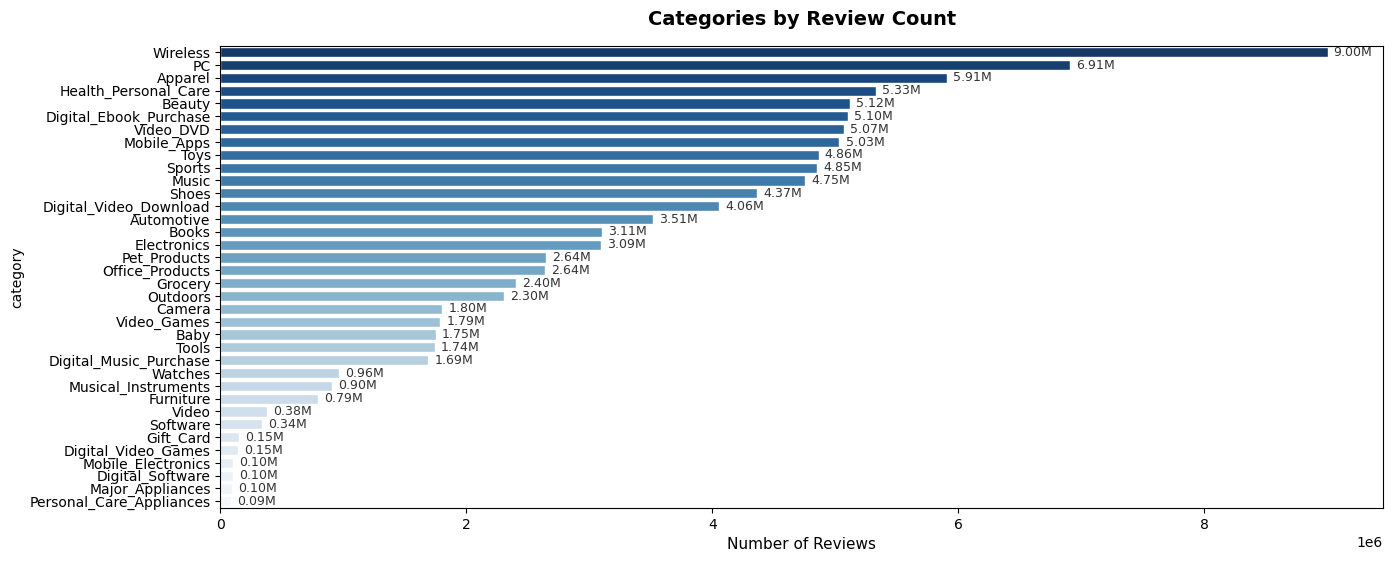

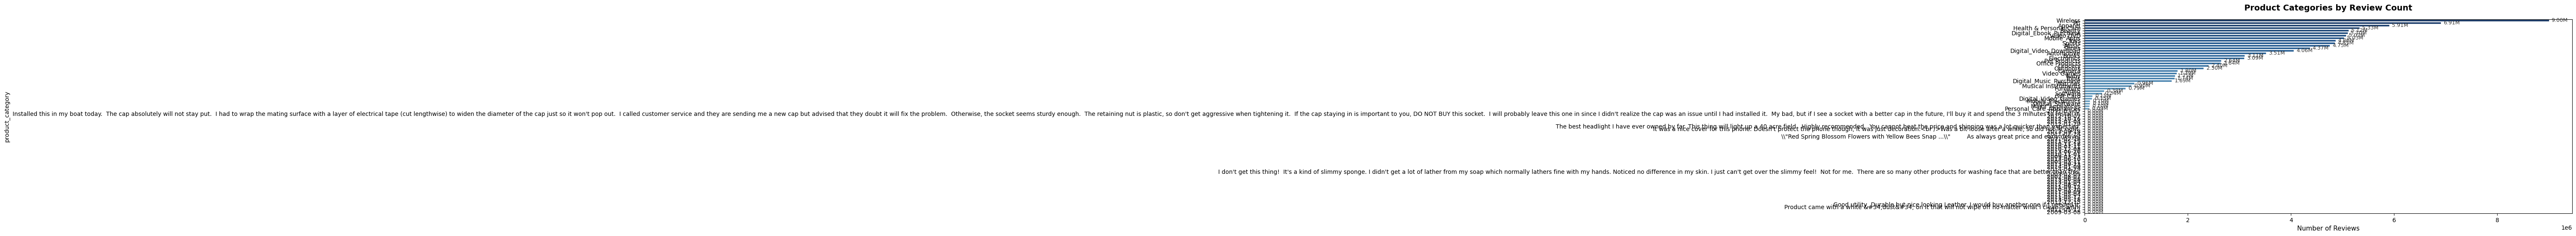

+----------------------+------------+
|product_category      |review_count|
+----------------------+------------+
|Wireless              |9001881     |
|PC                    |6908551     |
|Apparel               |5906322     |
|Health & Personal Care|5331215     |
|Beauty                |5115452     |
|Digital_Ebook_Purchase|5101676     |
|Video DVD             |5069136     |
|Mobile_Apps           |5033376     |
|Toys                  |4864243     |
|Sports                |4849563     |
+----------------------+------------+



In [12]:
# Product category distribution

plot_bar_chart(
    reviews_df, 
    'category', 
    'Number of Reviews',
    'Categories by Review Count'
)

plot_bar_chart(
    reviews_df, 
    'product_category', 
    'Number of Reviews',
    'Product Categories by Review Count'
)


# Let's play with the data. What are our most popular products?
top_categories = (
    reviews_df
    .groupBy('product_category')
    .agg(F.count('*').alias('review_count'))
    .orderBy(F.desc('review_count'))
    .limit(10)
)
top_categories.show(truncate=False)

**Observations**: 

Categories are highly unbalanced: there are a lot of technology/electronic-related categories.
That said they both have the highest and lowest count. 
This is an issue if our Machine Learning target was category classification.

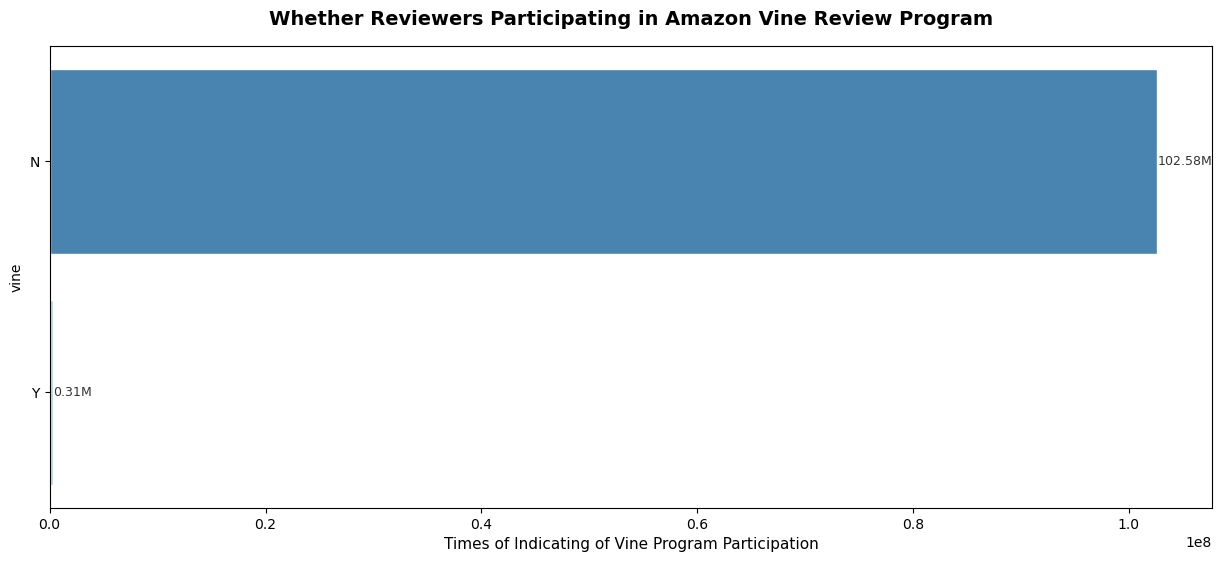

In [13]:
# Vine Distribution

plot_bar_chart(
    reviews_df, 
    'vine', 
    'Times of Indicating of Vine Program Participation', 
    'Whether Reviewers Participating in Amazon Vine Review Program'
)

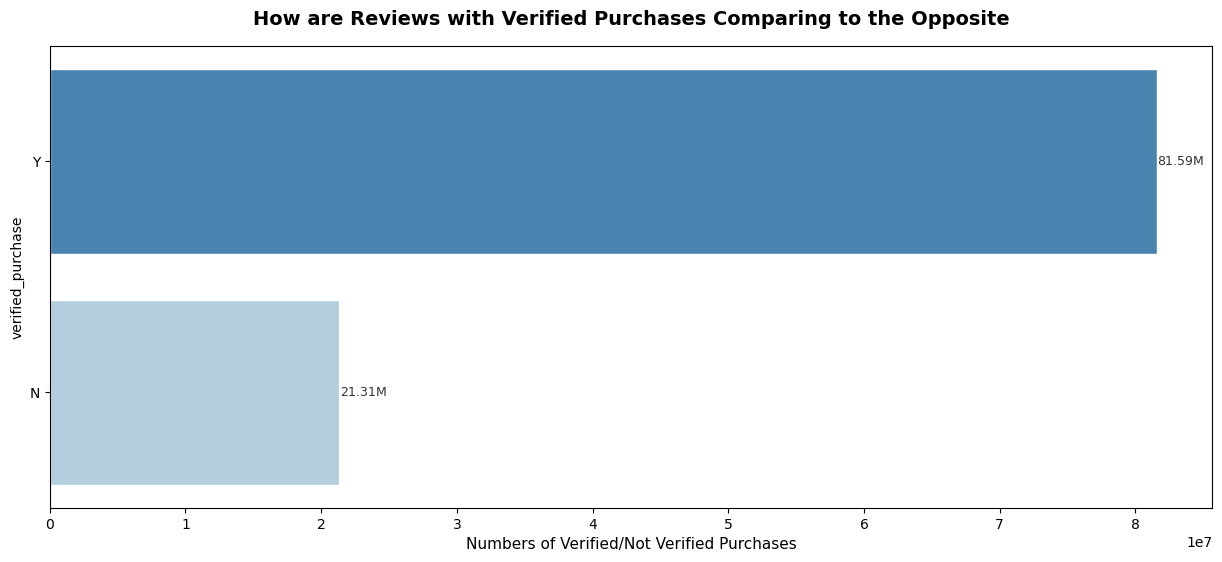

In [14]:
# Verified Purchase Distribution

plot_bar_chart(
    reviews_df, 
    'verified_purchase', 
    'Numbers of Verified/Not Verified Purchases', 
    'How are Reviews with Verified Purchases Comparing to the Opposite'
)

**Observations**:

The class for Vine is extremely imbalanced, and verified_purchases it's better but 'Y' has 60% more data than 'N'

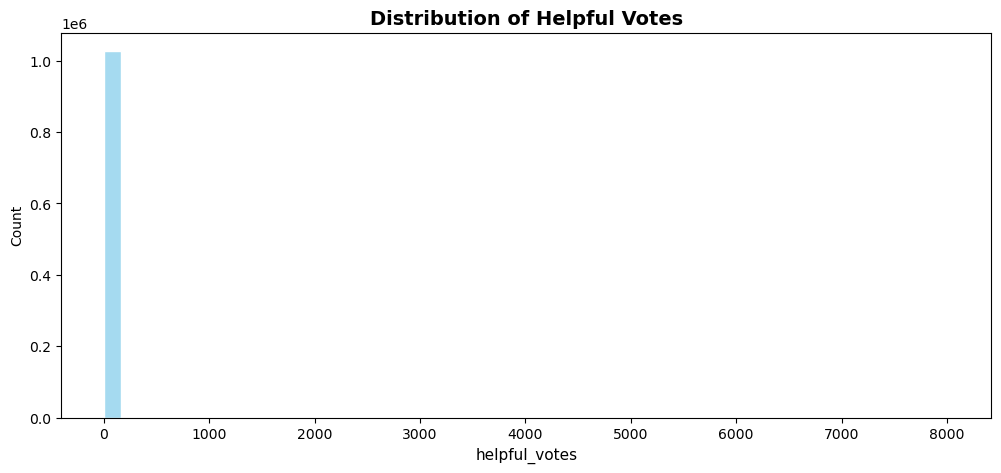

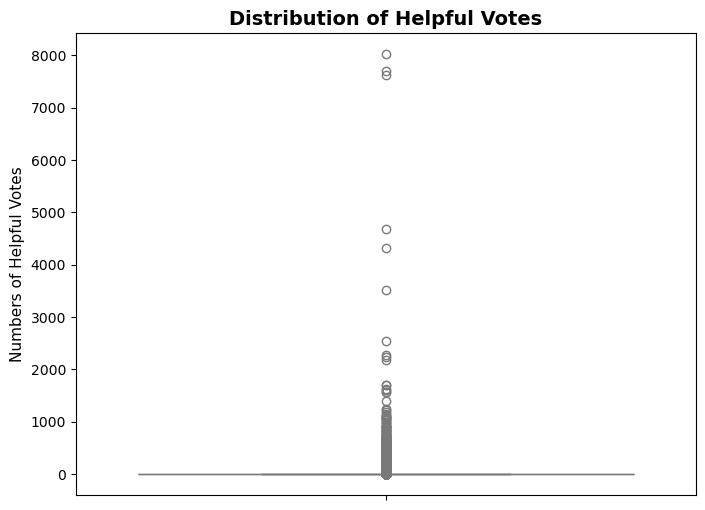

In [16]:
# Helpful Votes Distribution

plot_histogram(
    reviews_df, 
    'helpful_votes', 
    'Numbers of Helpful Votes', 
    'Distribution of Helpful Votes'
)

plot_boxplot(
    reviews_df, 
    'helpful_votes', 
    'Numbers of Helpful Votes', 
    'Distribution of Helpful Votes'
)

**Observations**:

Helpful votes is higher desnity closer to 0, while having extereme outlier value such at 8000. It would be interesting to check the review with outlier value amount that are more than 2000. So this column has extreme skewed distribution to lower values or none at all.

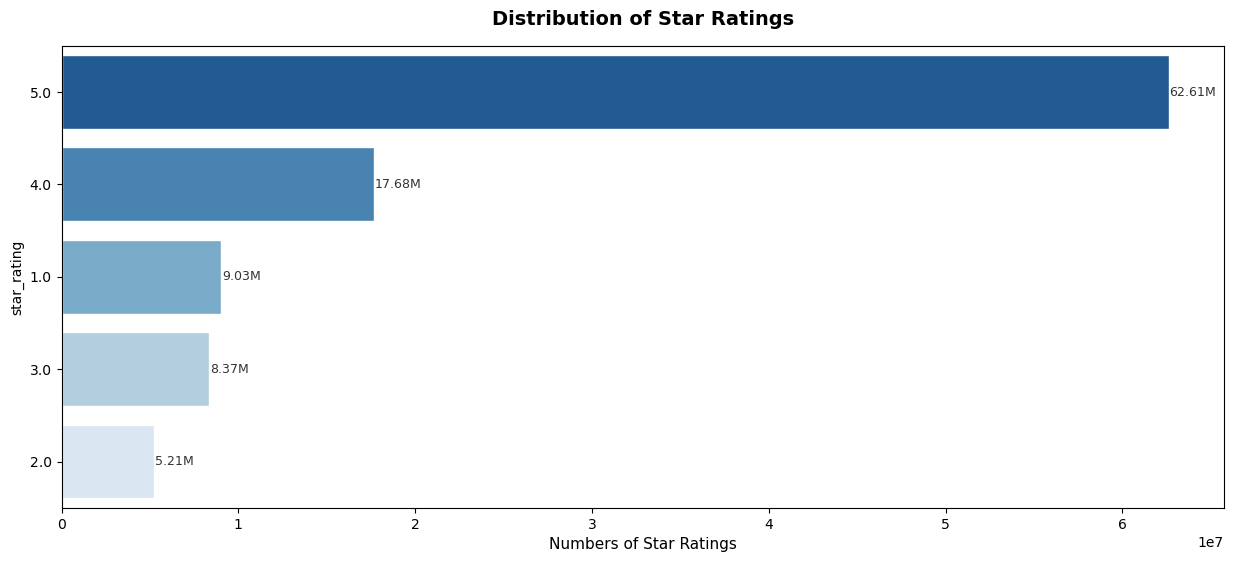

In [17]:
# Rating Distribution

plot_bar_chart(
    reviews_df, 
    'star_rating', 
    'Numbers of Star Ratings', 
    'Distribution of Star Ratings'
)

### Sport Analysis

In [18]:
# Let's focus on a sports-specific data frame for plotting 
# since sports have the lowest review counts among the most popular categories

# We'll scale this up for our own needs with all the data in the future
sports_df = (
    reviews_df
    .filter(F.lower(F.col('product_category')) == 'sports')
)

# materialize cache (important)
sports_df.cache()

# Row and memory counts for sports_df
row_memory_count(sports_df)

Total row counts: 4849563 rows
Total estimated size: 5.11 GB


**Observations**: 

- We can see that sports_df occupied about 5 GB of data, which is why setting the memory of 4GB per executor does not work
- We already know that the review_df has (total row: 102899354, total size: 118.75 GB), since sports_df row counts is around 4% of the review_df row counts, so it's reasonable to directly estimate that sports_df memory is around 4% of review_df's.

In [19]:
# How about if we check for the unique sports products by product_id

distinct_sports_products = (
    sports_df
    .select('product_id')
    .distinct()
    .count()
)
print(f'Distinct Sports products: {distinct_sports_products}')

Distinct Sports products: 1046129


+----------+-----+
|product_id|count|
+----------+-----+
|B001HBHNHE|7405 |
|7245456313|3693 |
|B00FX0S4DC|3051 |
|B000UVVX28|3006 |
|B002QZ1RS6|2922 |
|B003TJH3LI|2823 |
|B005M1P85O|2786 |
|B001EJMS6K|2560 |
|B00178CS4K|2299 |
|B00B1N0R6C|2278 |
+----------+-----+



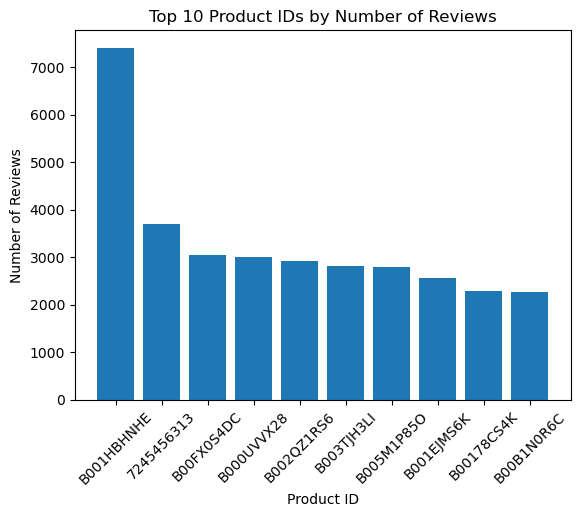

In [20]:
# --- Data ---
top10_products = (
    sports_df
    .groupBy('product_id')
    .count()
    .orderBy(F.desc('count'))
    .limit(10)
)
top10_products.show(truncate=False)
top10_pd = top10_products.toPandas()

# --- Plot ----
plt.figure()
plt.bar(top10_pd['product_id'], top10_pd['count'])
plt.xticks(rotation = 45)
plt.xlabel('Product ID')
plt.ylabel('Number of Reviews')
plt.title('Top 10 Product IDs by Number of Reviews')
plt.show()

**Observation**:

The result shows that many products receive at least one review, so unique product count < total row count

In [21]:
# Discretize star rating 
# (As it was defined to be an integer, this just ensures it works as expected)

sports_df_clean = (
    sports_df
    .withColumn("star_rating_int", F.expr("try_cast(star_rating as int)"))
    .filter(F.col("star_rating_int").isNotNull())
)

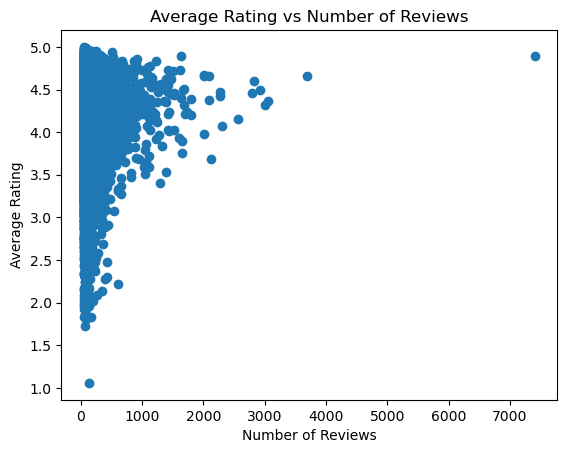

In [22]:
# We want to see if number of review correlates with average ratings

# --- Data ---
average_rating_df = (
    sports_df_clean  
    .groupBy("product_id")
    .agg(
        F.avg("star_rating_int").alias("avg_rating"),
        F.count("*").alias("num_reviews")
    )
     # avoid tiny sample noise
    .filter(F.col("num_reviews") > 50) 
)
average_rating_pd = average_rating_df.toPandas()

# --- Plot ---
plt.figure()
plt.scatter(average_rating_pd['num_reviews'], average_rating_pd['avg_rating'])
plt.xlabel('Number of Reviews')
plt.ylabel('Average Rating')
plt.title('Average Rating vs Number of Reviews')
plt.show()

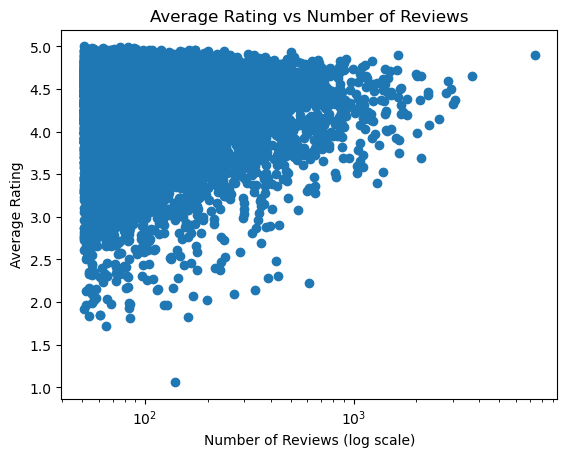

In [23]:
# We want to see it in log plot

plt.figure()
plt.scatter(average_rating_pd['num_reviews'], average_rating_pd['avg_rating'])
plt.xscale('log')
plt.xlabel('Number of Reviews (log scale)')
plt.ylabel('Average Rating')
plt.title('Average Rating vs Number of Reviews')
plt.show()

## Milestone 3 & 4 Data Preprocessing 

In [95]:
## MORE PLAN

# Sentiment Score via Vander Sentiment or Spark NLP DL Sentiment

# Text EDA

# A lot of things from here:
# https://www.kaggle.com/code/asadozzaman/text-data-preprocessing-sentiment-analysis#Step-1:Importing-Libraries

# Understand the process more through:
# train_df.explain(extended=True)
# train_final.rdd.toDebugString()

### Import & Install Modules

In [132]:
# Milestone 4: We need to install a library for sentiment analysis 
# Vader works well with text along the lines of social media
!pip install vaderSentiment

Defaulting to user installation because normal site-packages is not writeable


In [133]:
from pyspark.sql.types import FloatType
from pyspark.ml import Transformer, Pipeline
from pyspark.ml.param.shared import Param, Params
from pyspark.ml.feature import (
    StringIndexer, VectorAssembler, 
    StandardScaler, SQLTransformer,
    Tokenizer, StopWordsRemover,
    HashingTF, IDF, PCA
)
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier,
    NaiveBayes, LinearSVC, OneVsRest
)
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator, 
    ClusteringEvaluator,
    RegressionEvaluator
)
from xgboost.spark import SparkXGBClassifier
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time

### Subsample Dataframe for Testing (Row Sampling)

In [134]:
# Only use for subsampling
preprocess_df = (
    reviews_df
    .sample(
        withReplacement=False, 
        fraction=0.01
    )
)

# Only use for production
# preprocess_df = reviews_df

start = time.time()

### Relevant Features for ML (Feature Selection)

| Column            | Status | Justification / Impact                                                                                              |
| ----------------- | ------ | ------------------------------------------------------------------------------------------------------------------- |
| marketplace       | ✅ / ❌    | Restrict to U.S. marketplace for English-language consistency; won’t add predictive value after filtering           |
| customer_id       | ✅ / ❌      | Could allow aggregation of user behavior but not essential |
| review_id         | ❌      | Unique key only; no predictive value                                                                                |
| product_id        | ✅ / ❌      | Enables aggregation to detect product-specific rating tendencies, could allow aggregation of product behavior but not essential                    |
| product_parent    | ❌    | We can just rely on product_id                      |
| product_title     | ✅      | Useful for sanity-checking product_id; can be tokenized for NLP features if needed, not needed now                                |
| category  | ✅      | rating could be different based on categories, and different categories may have varying rating distributions                       |
| product_category  | ❌      |  This is a redundant features that overlaps with category and contains some random values as categories such as review and datetime type                           |
| star_rating       | ✅✅✅   | Target variable; ranking matters but intervals may not be perfectly aligned                                         |
| helpful_votes     | ✅ / ❌    | Indicates perceived usefulness; can combine with total_votes to create helpfulness ratio, after that, we don't need it anymore                            |
| total_votes       | ✅      | Indicates overall engagement; can combine with helpful_votes to measure helpfulness ratio                           |
| vine              | ❌    | Binary; Amazon Vine reviews may indicate incentivized reviews, extreme class imbalance issues                                       |
| verified_purchase | ✅      | Affects credibility; verified reviews may correlate with stronger sentiment, obvious class imbalance                                         |
| review_headline   | ✅      | Useful for NLP; headlines often contain strong sentiment signals                                                 |                                                |
| review_body       | ✅      | Primary feature for NLP: tokenization, sentiment analysis, review length, vocabulary frequency                      |
| review_date       | ❌      | Despite enabling seasonality/trend analysis; can be transformed into month, year, or holiday-period indicators, we will need time-awared version of train/test split, which is not available in Spark MLlib            |


In [135]:
# Discard features with strictly ❌ sign

preprocess_df = (
    preprocess_df
    # Discard irrelevant features
    .select([
        feat 
        for feat in reviews_df.columns 
        if feat not in [
        'customer_id',
        'product_id',
        'product_title',
        'review_id',
        'product_parent',
        'product_category',
        'vine',
        'review_date'
        ]
    ])
    # Discard feature 'marketplace' after filtering
    .filter(F.col('marketplace') == 'US')
    .drop('marketplace')
    .withColumn("star_rating", F.col("star_rating").cast("double"))
)

### Handle Missing Values (Row Filtering & Value Imputation)

In [136]:
# Remove the missing rows for star rating columns
# We don't want to impute any artificial values 

# Perform list-wise deletion
preprocess_df = preprocess_df.filter(
    F.col("star_rating").isNotNull()
)

In [137]:
# Impute the missing rows for features with specific value 
# I did not use pyspark.ml.feature.Imputer and use pyspark.sql.DataFrame.fillna instead
# Because I need fill out non-numeric features and in this case, constant imputation is better than statistical imputation while efficient

preprocess_df = preprocess_df.fillna({
    'category': 'Unknown',
    "verified_purchase": "Unknown",
    "review_headline": "",
    "review_body": "",
    'helpful_votes': 0,
    'total_votes': 0
})

### Create New Features (Feature Engineering)

In [138]:
# Define Sentiment Analyzer object & UDF
analyzer= SentimentIntensityAnalyzer()
def vader_sentiment(text):
    if text is None:
        return 0.0
    return float(analyzer.polarity_scores(text)['compound'])
sentiment_udf = F.udf(vader_sentiment, FloatType())

preprocess_df = (
    preprocess_df
    .withColumns({
    # # --- Interaction features ---
    # "sentiment_x_length": F.col("body_sentiment_score") * F.col("review_len"),

    # "sentiment_x_helpfulness": F.col("body_sentiment_score") * F.col("helpful_ratio"),

    # # --- Simple emphasis signals ---
    # "num_exclamations": F.length("review_body") - F.length(F.regexp_replace("review_body", "!", "")),

    # # --- Caps ratio ---
    # "num_uppercase": F.length("review_body") - F.length(F.regexp_replace("review_body", "[A-Z]", "")),

    # "uppercase_ratio": F.when(
    #     F.col("review_len") > 0,
    #     F.col("num_uppercase") / F.col("review_len")
    # ).otherwise(0)    

    # --- Length-based ---
        # Numbers of characters in review 
        "review_len": F.length("review_body"),

        # Numbers of words in review
        "review_word_counts": F.size(
            F.split(F.col("review_body"), " ")
        ),

        # Numbers of characters in review headline 
        "review_headline_len": F.length("review_headline"),

        # Numbers of words in review headline 
        "review_headline_word_counts": F.size(
            F.split(F.col("review_headline"), " ")
        ),

        # Average word length
        "avg_word_length": F.when(
            F.col("review_word_counts") > 0,
            F.col("review_len") / F.col("review_word_counts")
        ).otherwise(0),

    # --- Emphasis-based ---
        "num_exclamations": F.length("review_body") - F.length(F.regexp_replace("review_body", "!", "")),

        "num_uppercase": F.length("review_body") - F.length(F.regexp_replace("review_body", "[A-Z]", "")),
        
    # --- Ratio-based ---
        # This may expose future info, which potentially data leakage
        "helpful_ratio": F.when(
            F.col("total_votes") > 0,
            F.col("helpful_votes") / F.col("total_votes")
        ).otherwise(0),

        # Relative ratio between headline and body
        "headline_body_length_ratio": F.when(
            F.col("review_len") > 0,
            F.col("review_headline_len") / F.col("review_len")
        ).otherwise(0),

        "uppercase_ratio": F.when(
            F.col("review_len") > 0,
            F.col("num_uppercase") / F.col("review_len")
        ).otherwise(0),


    # --- Sentiment-based ---
        "body_sentiment_score": sentiment_udf(F.col("review_body")),
        
        "headline_sentiment_score": sentiment_udf(F.col("review_headline")),

        "sentiment_gap": F.col("body_sentiment_score") - F.col("headline_sentiment_score"),

        "abs_body_sentiment": F.abs(F.col("body_sentiment_score")),

    # --- Feature Interaction-based ---
        "sentiment_x_length": F.col("body_sentiment_score") * F.col("review_len"),

        "sentiment_x_helpfulness": F.col("body_sentiment_score") * F.col("helpful_ratio")
    })
    # Adjust rating by rating - 1
    .withColumn(
        "label",
        F.col("star_rating") - 1
    )
    # Drop unused features
    .drop("helpful_votes")
    .drop("star_rating")
)

preprocess_df.select([    
    "review_len",
    "review_word_counts",
    "review_headline_len",
    "review_headline_word_counts",
    "avg_word_length",

    "num_exclamations",
    "num_uppercase",

    "helpful_ratio",
    "headline_body_length_ratio",
    "uppercase_ratio",
    
    "body_sentiment_score",
    "headline_sentiment_score",
    "sentiment_gap",
    "abs_body_sentiment",

    "sentiment_x_length",
    "sentiment_x_helpfulness",
    
    "label"
]).show(5)

+----------+------------------+-------------------+---------------------------+-----------------+----------------+-------------+------------------+--------------------------+--------------------+--------------------+------------------------+-------------+------------------+------------------+-----------------------+-----+
|review_len|review_word_counts|review_headline_len|review_headline_word_counts|  avg_word_length|num_exclamations|num_uppercase|     helpful_ratio|headline_body_length_ratio|     uppercase_ratio|body_sentiment_score|headline_sentiment_score|sentiment_gap|abs_body_sentiment|sentiment_x_length|sentiment_x_helpfulness|label|
+----------+------------------+-------------------+---------------------------+-----------------+----------------+-------------+------------------+--------------------------+--------------------+--------------------+------------------------+-------------+------------------+------------------+-----------------------+-----+
|        65|                

In [139]:
elapsed = time.time() - start
print(f"Preprocessing before train/test split took: {elapsed:.2f} seconds")

Preprocessing before train/test split took: 1.36 seconds


### Split Train/Test/Validation Sets (Row Sampling)

In [140]:
# Caching
preprocess_df = preprocess_df.persist(StorageLevel.MEMORY_AND_DISK)
preprocess_df.count()

train_df, val_df, test_df = preprocess_df.randomSplit(
    [0.7, 0.15, 0.15], 
    seed=42
)
train_df = train_df.persist(StorageLevel.MEMORY_AND_DISK)
train_df.count()

for df in [train_df, val_df, test_df]:
    row_memory_count(df)
    print()

Total row counts: 721028 rows
Total estimated size: 0.48 GB

Total row counts: 154549 rows
Total estimated size: 0.11 GB

Total row counts: 154464 rows
Total estimated size: 0.09 GB



### Encode Category Features (Feature Encoding)

In [141]:
# Define categorical encoding (string indexer) step 
indexer1 = StringIndexer(
    inputCol='verified_purchase',
    outputCol='verified_purchase_idx',
    handleInvalid='keep'
)

indexer2 = StringIndexer(
    inputCol="category",
    outputCol="category_idx",
    handleInvalid="keep"
)

**Observations**:

- helpful_ratio: Helpful Vote / Total Vote --> Relative Useful
- review_len & review_headline_len: Length of text should give more valuable information
- review_word_counts & review_headline_word_counts: Same reason above
- After checking their distribution through histograms, they all have long-tail right-skewed distribution

### Lower Text & Remove Special Characters (Text Canonicalization)

In [142]:
text_merge = SQLTransformer(
    statement="""
    SELECT *,
        concat(review_headline, ' ', review_body) AS review_text
    FROM __THIS__
    """
)

text_cleaner = SQLTransformer(
    statement="""
    SELECT *,
        regexp_replace(
            regexp_replace(
                lower(review_text),
                '[^a-zA-Z\\\\s]',
                ' '
            ),
            '\\\\s+',
            ' '
        ) AS clean_review_text
    FROM __THIS__
    """
)

### Tokenization & Stopword Removal (Text Canonicalization)

In [143]:
tokenizer = Tokenizer(
    inputCol="clean_review_text",
    outputCol="tokens"
)

stopwords = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens"
)

### Hash TF-IDF (Text Encoding)

In [144]:
hashing_tf = HashingTF(
    inputCol="filtered_tokens",
    outputCol="tf_features",
    numFeatures=2000
)

idf = IDF(
    inputCol="tf_features",
    outputCol="tfidf_features"
)

### Assemble relevant & Drop irrelevant features (Feature Engineering)

In [145]:
# Define numeric features to be kept
# Commented features show low importance from Random Forest model
feature_cols = [
    # 'verified_purchase_idx',
    # 'category_idx',
    
    "review_len",
    "review_word_counts",
    "review_headline_len",
    "review_headline_word_counts",
    # "avg_word_length",

    "num_exclamations",
    # "num_uppercase",

    # "helpful_ratio",
    "headline_body_length_ratio",
    # "uppercase_ratio",
    
    "body_sentiment_score",
    "headline_sentiment_score",
    "sentiment_gap",
    "abs_body_sentiment",

    "sentiment_x_length",
    # "sentiment_x_helpfulness",
]

## Define the assembler step
# Assemble them into arrays in form: 
# [helpful_ratio, total_votes, ..., 'review_headline_word_counts']
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="finalized_features"
)

# Define the drop step
col_remover = SQLTransformer(
    statement="""
    SELECT label, finalized_features
    FROM __THIS__
    """
)

### Pipeline

In [146]:
# Show dependency graph within the whole pipeline
'''
Preprocessing Pipeline Dependency Graph

# (NOT USED ANYMORE) CLASS WEIGHT and NUMERICAL FEATURE PROCESSING 
star_rating → class_weights_transformer
all numerical features → scaled_features

# NUMERIC FEATURE PROCESSING
+ New numeric features
+ Sentiment scores
+ label = star_rating - 1

# CATEGORICAL FEATURE PROCESSING
verified_purchase → indexer1
category → indexer2

→ → → → → → → → → → →BRANCH NORMAL → CATEGORICAL + NUMERIC → assembler → finalized_features
        ↓
        ↓
    BRANCH TEXT
        ↓
# TEXT FEATURE PROCESSING
review_headline + review_body
        ↓
    text_merge
        ↓
    text_cleaner
        ↓
    tokenizer → 
        ↓
    stopwords → 
        ↓
    HashTF + IDF
        ↓
    tfidf_features → CATEGORICAL + NUMERIC + TEXT → assembler_text → finalized_features
'''

'\nPreprocessing Pipeline Dependency Graph\n\n# (NOT USED ANYMORE) CLASS WEIGHT and NUMERICAL FEATURE PROCESSING \nstar_rating → class_weights_transformer\nall numerical features → scaled_features\n\n# NUMERIC FEATURE PROCESSING\n+ New numeric features\n+ Sentiment scores\n+ label = star_rating - 1\n\n# CATEGORICAL FEATURE PROCESSING\nverified_purchase → indexer1\ncategory → indexer2\n\n→ → → → → → → → → → →BRANCH NORMAL → CATEGORICAL + NUMERIC → assembler → finalized_features\n        ↓\n        ↓\n    BRANCH TEXT\n        ↓\n# TEXT FEATURE PROCESSING\nreview_headline + review_body\n        ↓\n    text_merge\n        ↓\n    text_cleaner\n        ↓\n    tokenizer → \n        ↓\n    stopwords → \n        ↓\n    HashTF + IDF\n        ↓\n    tfidf_features → CATEGORICAL + NUMERIC + TEXT → assembler_text → finalized_features\n'

In [147]:
# Define a partial pipeline, so that the resulting DF can split into two pipeline branches
pipeline_partial = (
    Pipeline(stages=[
        # CATEGORICAL FEATURE PROCESSING
        indexer1,
        indexer2,
    ])
    # Fit the pipeline
    .fit(train_df)
)
# Transform the pipeline & caching
train_partial = (
    pipeline_partial
    .transform(train_df)
    .persist(StorageLevel.MEMORY_AND_DISK)
)
val_partial = (
    pipeline_partial
    .transform(val_df)
    .persist(StorageLevel.MEMORY_AND_DISK)
)
test_partial = (
    pipeline_partial
    .transform(test_df)
    .persist(StorageLevel.MEMORY_AND_DISK)
)

# Force it to materialize
train_partial.count()
val_partial.count()
test_partial.count()

# Display df info
print("Schema for *_partial DF")
train_partial.printSchema()
for df in [train_partial, val_partial, test_partial]:
    row_memory_count(df)
    print('\n\n')

# Uncaching
preprocess_df.unpersist()
train_df.unpersist()

Schema for *_partial DF
root
 |-- total_votes: integer (nullable = false)
 |-- verified_purchase: string (nullable = false)
 |-- review_headline: string (nullable = false)
 |-- review_body: string (nullable = false)
 |-- category: string (nullable = false)
 |-- review_len: integer (nullable = false)
 |-- review_word_counts: integer (nullable = false)
 |-- review_headline_len: integer (nullable = false)
 |-- review_headline_word_counts: integer (nullable = false)
 |-- avg_word_length: double (nullable = true)
 |-- num_exclamations: integer (nullable = false)
 |-- num_uppercase: integer (nullable = false)
 |-- helpful_ratio: double (nullable = true)
 |-- headline_body_length_ratio: double (nullable = true)
 |-- uppercase_ratio: double (nullable = true)
 |-- body_sentiment_score: float (nullable = true)
 |-- headline_sentiment_score: float (nullable = true)
 |-- sentiment_gap: float (nullable = true)
 |-- abs_body_sentiment: float (nullable = true)
 |-- sentiment_x_length: float (nullable

DataFrame[total_votes: int, verified_purchase: string, review_headline: string, review_body: string, category: string, review_len: int, review_word_counts: int, review_headline_len: int, review_headline_word_counts: int, avg_word_length: double, num_exclamations: int, num_uppercase: int, helpful_ratio: double, headline_body_length_ratio: double, uppercase_ratio: double, body_sentiment_score: float, headline_sentiment_score: float, sentiment_gap: float, abs_body_sentiment: float, sentiment_x_length: float, sentiment_x_helpfulness: double, label: double]

In [148]:
num_partitions = 8 * 3

# Define a finalized pipeline without text
pipeline_normal = (
    Pipeline(stages=[         
        # FINAL FEATURE VECTOR
        assembler,
        
        # KEEP ONLY REQUIRED COLUMNS
        col_remover
    ])
    # Fit the pipeline
    .fit(train_partial)
)
# Transform the pipeline & caching
train_final = (
    pipeline_normal
    .transform(train_partial)
    .coalesce(num_partitions)
    .persist(StorageLevel.MEMORY_AND_DISK)
)
val_final = (
    pipeline_normal
    .transform(val_partial)
    .coalesce(num_partitions)
    .persist(StorageLevel.MEMORY_AND_DISK)
)
test_final = (
    pipeline_normal
    .transform(test_partial)
)

# Force it to materialize
train_final.count()
val_final.count()
test_final.count()

# Display df info
print("Schema for *_final DF")
train_final.printSchema()
for df in [train_final, val_final, test_final]:
    row_memory_count(df)
    print('\n\n')

Schema for *_final DF
root
 |-- label: double (nullable = true)
 |-- finalized_features: vector (nullable = true)

Total row counts: 721028 rows
Total estimated size: 0.03 GB



Total row counts: 154549 rows
Total estimated size: 0.01 GB



Total row counts: 154464 rows
Total estimated size: 0.01 GB





In [150]:
# Define a text pipeline using all previous steps
assembler_text = VectorAssembler(
    inputCols=feature_cols + ['tfidf_features'],
    outputCol="finalized_features"
)
pipeline_text = (
    Pipeline(stages=[
        # TEXT FEATURE PROCESSING
        text_merge,
        text_cleaner,
        tokenizer,
        stopwords,
        hashing_tf,
        idf,

        # FINAL FEATURE VECTOR
        assembler_text,
        
        # KEEP ONLY REQUIRED COLUMNS
        col_remover
    ])
    # Fit the pipeline
    .fit(train_partial)
)
# Transform the pipeline & caching
train_text = (
    pipeline_text
    .transform(train_partial)
    .coalesce(num_partitions)
    .persist(StorageLevel.MEMORY_AND_DISK)
)
val_text = (
    pipeline_text
    .transform(val_partial)
    .coalesce(num_partitions)
    .persist(StorageLevel.MEMORY_AND_DISK)
)
test_text = (
    pipeline_text
    .transform(test_partial)
)

# Force it to materialize
train_text.count()
val_text.count()
test_text.count()

# Display df info
print("Schema for *_text DF")
train_text.printSchema()
for df in [train_final, val_final, test_final]:
    row_memory_count(df)
    print('\n\n')

# Un-caching
train_partial.unpersist()
val_partial.unpersist()
test_partial.unpersist()

Schema for *_text DF
root
 |-- label: double (nullable = true)
 |-- finalized_features: vector (nullable = true)

Total row counts: 721028 rows
Total estimated size: 0.03 GB



Total row counts: 154549 rows
Total estimated size: 0.01 GB



Total row counts: 154464 rows
Total estimated size: 0.01 GB





DataFrame[total_votes: int, verified_purchase: string, review_headline: string, review_body: string, category: string, review_len: int, review_word_counts: int, review_headline_len: int, review_headline_word_counts: int, avg_word_length: double, num_exclamations: int, num_uppercase: int, helpful_ratio: double, headline_body_length_ratio: double, uppercase_ratio: double, body_sentiment_score: float, headline_sentiment_score: float, sentiment_gap: float, abs_body_sentiment: float, sentiment_x_length: float, sentiment_x_helpfulness: double, label: double, verified_purchase_idx: double, category_idx: double]

In [151]:
print("Train partitions:", train_final.rdd.getNumPartitions())
print("Val partitions:", val_final.rdd.getNumPartitions())
print("Test partitions:", test_final.rdd.getNumPartitions())

elapsed = time.time() - start
print(f"Preprocessing after train/test split took: {elapsed:.2f} seconds")

Train partitions: 24
Val partitions: 24
Test partitions: 384
Preprocessing after train/test split took: 1202.78 seconds


### WE AREN'T USING THIS ANYMORE BUT IT'S HERE FOR RECORD PURPOSES

In [121]:
# ## Handle Unbalanced Classes (Feature Engineering)
# ## Motivation: Class imbalance was identified during EDA, thought that reweighting would helps model performance
# ## Result: Model actually improved by 2-3% accuracy when not used, so I have to give up

# # Gather class count
# weight_total_count = train_df.count()
# weight_class_counts = (
#     train_df
#     .groupBy('star_rating')
#     .count()
#     .collect()
# )
# # Get weights as dictionary
# num_classes = len(weight_class_counts)
# weights_map = {
#     class_row['star_rating'] : weight_total_count / (num_classes * class_row["count"])
#     for class_row in weight_class_counts
# }

# # Define the transformer class to wrap around this operation
# class ClassWeightAdder(Transformer):
#     def __init__(self, inputCol="star_rating", outputCol="class_weight", weights_map=None):
#         super().__init__()
#         self.inputCol = inputCol
#         self.outputCol = outputCol
#         self.weights_map = weights_map or {}

#     def _transform(self, df):
#         # create Spark Map literal
#         weights_spark = [
#             F.lit(x) 
#             for kv in self.weights_map.items() 
#             for x in kv
#         ]
        
#         return df.withColumn(
#             self.outputCol,
#             F.create_map(weights_spark)[F.col(self.inputCol)]
#         )

# # Define the class re-weighting step
# class_weights_transformer = ClassWeightAdder(
#     inputCol="star_rating",
#     outputCol="class_weight",
#     weights_map=weights_map
# )

# ## Handle Skew Distribution (Feature Scaling)
# ## Motivation: Distribution skewness was identified during EDA, thought it might helps model with standard norm dist assumption
# ## Result: It has no effect for linear model and tree models, so I gave up

# # Define numeric features to be scaled
# feature_cols1 = [
#     "total_votes",
#     "helpful_ratio",
#     "review_len",
#     "review_word_counts",
#     "review_headline_len",
#     "review_headline_word_counts"
# ]

# ## Define the assembler step
# # Assemble them into arrays in form: 
# # [helpful_ratio, total_votes, ..., 'review_headline_word_counts']
# assembler1 = VectorAssembler(
#     inputCols=feature_cols1,
#     outputCol="assembled_features"
# )

# # Define the standard scaling step
# # Scale numeric features that are skewed
# scaler = StandardScaler(
#     inputCol="assembled_features",
#     outputCol="scaled_features",
#     withMean=True,
#     withStd=True
# )

## Milestone 3 & 4 Modeling Tasks Setup

In [124]:
# For XGBoost param setup
num_executors = int(sc.getConf().get("spark.executor.instances", "1"))
executor_cores = int(sc.getConf().get("spark.executor.cores", "1"))
total_cores = num_executors * executor_cores

# Define model definition
models = {
    "log_reg": LogisticRegression(
        featuresCol="finalized_features",
        labelCol="label",
        predictionCol='prediction',
        maxIter=20
    ),

    "random_forest": RandomForestClassifier(
        featuresCol="finalized_features",
        labelCol="label",
        predictionCol='prediction',
        numTrees=25,
        maxDepth=8,
        maxBins=37
    ),

    "naive_bayes": NaiveBayes(
        featuresCol="finalized_features",
        labelCol="label",
        predictionCol='prediction',
    ),

    "svm": LinearSVC(
        featuresCol="finalized_features",
        labelCol="label",
        predictionCol='prediction',
        maxIter=20,
        regParam=0.1
    ),

    "xgb": SparkXGBClassifier(
        features_col='finalized_features',
        label_col='label',
        prediction_col='prediction',
        num_workers=total_cores,
        max_depth=8,
        n_estimators=50,
        eta=0.1,
        subsample=0.8,
        colsample_bytree=0.8
    )
}

def helper_fit_transform(
    model_name,
    train_final_df,
    test_final_df,
    label_col="label",
    feat_col="finalized_features",
    pred_col="prediction",
    one_versus_all=False,
    cache=False
):
    if model_name not in models:
        raise ValueError("Model Name NOT FOUND!!!")        
    
    # Define model & ova model  
    model = models[model_name]
    if one_versus_all:
        model = OneVsRest(
            classifier=model,
            featuresCol=feat_col,
            labelCol=label_col,
            predictionCol=pred_col
        )

    # Fit and transform
    fitted = model.fit(train_final_df)
    train_pred_df = fitted.transform(train_final_df)
    test_pred_df = fitted.transform(test_final_df)

    # Cache if requested
    if cache:
        train_pred_df = train_pred_df.persist(StorageLevel.MEMORY_AND_DISK)
        test_pred_df = test_pred_df.persist(StorageLevel.MEMORY_AND_DISK)

        # Force it to materialize
        train_pred_df.count()
        test_pred_df.count()
    
    return fitted, train_pred_df, test_pred_df

def helper_evaluate_model(
    model_name,
    train_pred_df, 
    test_pred_df,
    label_col="label", 
    metrics=["f1", "weightedPrecision", "weightedRecall", "accuracy"],
    verbose=True
):
    metric_data = {}
    
    # Define for each metric
    for metric in metrics:
        evaluator = MulticlassClassificationEvaluator(
            labelCol=label_col,
            predictionCol="prediction",
            metricName=metric
        )
        
        # Compute metric
        train_score = evaluator.evaluate(train_pred_df)
        test_score = evaluator.evaluate(test_pred_df)

        if verbose:
            # Display result
            print(f"{model_name} Train {metric}: {train_score:.4f}")
            print(f"{model_name} Test {metric}: {test_score:.4f}")
            print()
    
        # Store results
        metric_data[metric] = [train_score, test_score]
    return metric_data

## Milestone 3 Modeling Task - Supervised ML Models

### Logistic Regression

In [125]:
start = time.time()

lr, lr_train_pred, lr_val_pred = helper_fit_transform(
    'log_reg', 
    train_text, val_text
)
helper_evaluate_model(
    'log_reg', 
    lr_train_pred, lr_val_pred
)

elapsed = time.time() - start
print(f"ML Logistic Regression took: {elapsed:.2f} seconds")

log_reg Train f1: 0.6936
log_reg Test f1: 0.6878

log_reg Train weightedPrecision: 0.6981
log_reg Test weightedPrecision: 0.6909

log_reg Train weightedRecall: 0.7270
log_reg Test weightedRecall: 0.7219

log_reg Train accuracy: 0.7270
log_reg Test accuracy: 0.7219

ML Logistic Regression took: 8.85 seconds


### Linear Support Vector Classifier

In [126]:
start = time.time()

svc, svc_train_pred, svc_val_pred = helper_fit_transform(
    'svm', 
    train_text, val_text, 
    one_versus_all=True,
    cache=True
)
helper_evaluate_model(
    'svm', 
    svc_train_pred, svc_val_pred
)

elapsed = time.time() - start
print(f"ML Linear Support Vector Classifier took: {elapsed:.2f} seconds")

svm Train f1: 0.6326
svm Test f1: 0.6293

svm Train weightedPrecision: 0.6631
svm Test weightedPrecision: 0.6560

svm Train weightedRecall: 0.6991
svm Test weightedRecall: 0.6965

svm Train accuracy: 0.6991
svm Test accuracy: 0.6965

ML Linear Support Vector Classifier took: 39.10 seconds


### Random Forest

In [159]:
# Uncache, we don't need these df anymore
train_text.unpersist()
val_text.unpersist()

start = time.time()

rf_a, rf_train_a_pred, rf_val_a_pred = helper_fit_transform(
    'random_forest', 
    train_final, 
    val_final,
    cache=True
)
helper_evaluate_model(
    'random_forest', 
    rf_train_a_pred, rf_val_a_pred
)

elapsed = time.time() - start
print(f"ML Random Forest took: {elapsed:.2f} seconds")

random_forest Train f1: 0.5649
random_forest Test f1: 0.5639

random_forest Train weightedPrecision: 0.6952
random_forest Test weightedPrecision: 0.6717

random_forest Train weightedRecall: 0.6656
random_forest Test weightedRecall: 0.6643

random_forest Train accuracy: 0.6656
random_forest Test accuracy: 0.6643

ML Random Forest took: 9.86 seconds


### XGBoost

In [160]:
start = time.time()

# Temp preprocess data to avoid XGBoost error for N class expecting class value starting at 0
xgb_train_final = train_final.withColumn("label", F.col("label").cast("int"))
xgb_val_final   = val_final.withColumn("label", F.col("label").cast("int"))

xgb, xgb_train_pred, xgb_val_pred = helper_fit_transform(
    'xgb', 
    xgb_train_final, xgb_val_final
)
helper_evaluate_model(
    'xgb', 
    xgb_train_pred, xgb_val_pred
)

elapsed = time.time() - start
print(f"ML XGBoost took: {elapsed:.2f} seconds")

INFO:XGBoost-PySpark:Running xgboost-2.0.3 on 8 workers with
	booster params: {'objective': 'multi:softprob', 'colsample_bytree': 0.8, 'device': 'cpu', 'max_depth': 8, 'subsample': 0.8, 'eta': 0.1, 'num_class': 5, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 50}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!


xgb Train f1: 0.5955
xgb Test f1: 0.5903

xgb Train weightedPrecision: 0.6448
xgb Test weightedPrecision: 0.6302

xgb Train weightedRecall: 0.6779
xgb Test weightedRecall: 0.6734

xgb Train accuracy: 0.6779
xgb Test accuracy: 0.6734

ML XGBoost took: 33.14 seconds


### Visualize the Graph of Fit of Models

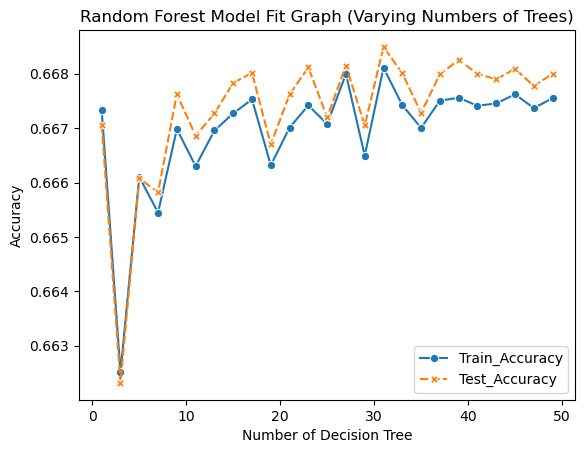

ML Fit Graph (varying numbers of decision trees) took: 248.59 seconds


,Train_Accuracy,Test_Accuracy
1,0.667332,0.667061
3,0.662513,0.662317
5,0.666101,0.666078
7,0.665447,0.665819
9,0.666983,0.667625
11,0.666301,0.666861
13,0.666956,0.667269
15,0.667269,0.667832
17,0.667530,0.668013
19,0.666316,0.666699


In [26]:
start = time.time()

# Initialize the metric array
train_metrics, test_metrics = [], []

# Iterate it N times
start_num = 1
end_num = 50
for i in range(start_num, end_num, 2):
    rf_graph_fit = RandomForestClassifier(
        featuresCol="finalized_features",
        labelCol="label",
        predictionCol='prediction',
        numTrees=i,
        maxDepth=8,
        maxBins=37
    )
    models['random_forest_graph_fit'] = rf_graph_fit
 
    
    # Train & predict
    _, rf_train_pred, rf_val_pred = helper_fit_transform(
        'random_forest_graph_fit', 
        train_final, val_final,
    )

    # Evaluate
    rf_metrics = helper_evaluate_model(
        'random_forest_graph_fit', 
        rf_train_pred, 
        rf_val_pred, 
        metrics=["accuracy"],
        verbose=False
    )
    
    # Append results
    train_metrics.append(rf_metrics['accuracy'][0])
    test_metrics.append(rf_metrics['accuracy'][1])

# Store results
df = pd.DataFrame(
    data={
        'Train_Accuracy': train_metrics,
        'Test_Accuracy': test_metrics
    }, 
    index=range(start_num, end_num, 2)
)
df_reset = df.reset_index().rename(columns={'index': 'NumTrees'})
print(df_reset)

sns.lineplot(df, markers=True)
plt.title("Random Forest Model Fit Graph (Varying Numbers of Trees)")
plt.xlabel("Number of Decision Tree")
plt.ylabel("Accuracy")
plt.show()

elapsed = time.time() - start
print(f"ML Fit Graph (varying numbers of decision trees) took: {elapsed:.2f} seconds")

ML Fit Graph (varying tree depth) took: 58.95 seconds


,Train_Accuracy,Test_Accuracy
1,0.608990,0.609100
3,0.630194,0.630434
5,0.641967,0.642155
7,0.663839,0.664550
9,0.669793,0.670097
11,0.675547,0.673586
13,0.686034,0.675625


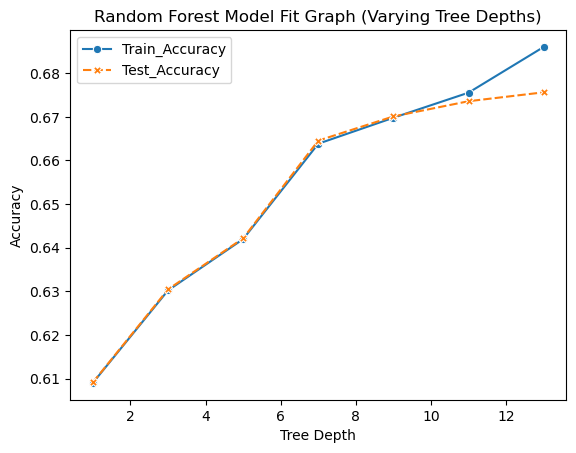

In [27]:
start = time.time()

# Initialize the metric array
train_metrics, test_metrics = [], []

# Iterate it N times
start_num = 1
end_num = 15
for i in range(start_num, end_num, 2):
    rf_graph_fit = RandomForestClassifier(
        featuresCol="finalized_features",
        labelCol="label",
        predictionCol='prediction',
        numTrees=15,
        maxDepth=i,
        maxBins=37
    )
    models['random_forest_graph_fit'] = rf_graph_fit
 
    
    # Train & predict
    _, rf_train_pred, rf_val_pred = helper_fit_transform(
        'random_forest_graph_fit', 
        train_final, val_final
    )

    # Evaluate
    rf_metrics = helper_evaluate_model(
        'random_forest_graph_fit', 
        rf_train_pred, 
        rf_val_pred, 
        metrics=["accuracy"],
        verbose=False
    )
    
    # Append results
    train_metrics.append(rf_metrics['accuracy'][0])
    test_metrics.append(rf_metrics['accuracy'][1])

# Store results
df = pd.DataFrame(
    data={
        'Train_Accuracy': train_metrics,
        'Test_Accuracy': test_metrics
    }, 
    index=range(start_num, end_num, 2)
)
df_reset = df.reset_index().rename(columns={'index': 'Depth'})
print(df_reset)

sns.lineplot(df, markers=True)
plt.title("Random Forest Model Fit Graph (Varying Tree Depths)")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")

elapsed = time.time() - start
print(f"ML Fit Graph (varying tree depth) took: {elapsed:.2f} seconds")

### Let's try playing around with the hyper parameters. We're going change the trees and depths.

In [81]:
start = time.time()

In [130]:
# Definition
rf_b = RandomForestClassifier(
    featuresCol='finalized_features',
    labelCol='label',
    predictionCol='prediction',
    numTrees=20,
    maxDepth=6,
    maxBins=37,
)
models['random_forest_b'] = rf_b

# Fit and Transform
rf_model_b, rf_train_b_pred, rf_val_b_pred = helper_fit_transform(
    'random_forest_b',
    train_final,
    val_final,
    cache=True
)

# Evaluate
print(f'SET B:')
helper_evaluate_model(
    'random_forest_b',
    rf_train_b_pred, rf_val_b_pred
)
print()

SET B:
random_forest_b Train f1: 0.5383
random_forest_b Test f1: 0.5374

random_forest_b Train weightedPrecision: 0.5765
random_forest_b Test weightedPrecision: 0.5763

random_forest_b Train weightedRecall: 0.6517
random_forest_b Test weightedRecall: 0.6514

random_forest_b Train accuracy: 0.6517
random_forest_b Test accuracy: 0.6514




In [129]:
# Define model with weightCol
rf_c = RandomForestClassifier(
    featuresCol='finalized_features',
    labelCol='label',
    predictionCol='prediction',
    numTrees=15,
    maxDepth=15,
    maxBins=37,
)
models['random_forest_c'] = rf_c

# Fit and Transform
rf_model_c, rf_train_c_pred, rf_val_c_pred = helper_fit_transform(
    'random_forest_c',
    train_final,
    val_final,
    cache=True
)

# Evaluate
print(f'SET C:')
helper_evaluate_model(
    'random_forest_c',
    rf_train_c_pred, rf_val_c_pred
)
print()

SET C:
random_forest_c Train f1: 0.6486
random_forest_c Test f1: 0.5909

random_forest_c Train weightedPrecision: 0.7253
random_forest_c Test weightedPrecision: 0.6106

random_forest_c Train weightedRecall: 0.7145
random_forest_c Test weightedRecall: 0.6728

random_forest_c Train accuracy: 0.7145
random_forest_c Test accuracy: 0.6728




In [84]:
elapsed = time.time() - start
print(f"ML Hyperparameter Tuning took: {elapsed:.2f} seconds")

ML Hyperparameter Tuning took: 112.78 seconds


**Observations**:

- This is where knowing your Spark set-up matters. We've run into heap issues exploring this data when the tree count grows.
- We believe that we're going to have work more on our features. If LR and RF are at the same level, then we're going to have to improve something
- We may re-use some combo of B or C here, but again this all becomes a heap issue.
- The distributed computing is GREAT! Seriously we're getting through Gigabytes of Data, in minutes. We ran this notebook in under 30 minutes with our Milestone 2!


We've reached out to our instructors regarding the size of our data as the training and validation are taking up a lot of overhead. We decided to stick to a smaller subset of the whole. Right now, we're running 1% well enough in terms of speed, and we want to scale up to 5%/10%.



Let's see what the plots can tell us. We're going to use the pyspark.ml.evaluation library:

### Comparison Between Models

In [ ]:
## Define evaluator 
rmse_evaluator = RegressionEvaluator(
    labelCol='label',
    predictionCol='prediction',
    metricName='rmse'
)

## Evaluate model
# Logistic Regression
lr_train_rmse = rmse_evaluator.evaluate(lr_train_pred)
lr_val_rmse = rmse_evaluator.evaluate(lr_val_pred)

# Linear SVC
svc_train_rmse = rmse_evaluator.evaluate(svc_train_pred)
svc_val_rmse = rmse_evaluator.evaluate(svc_val_pred)

# Random Forest A
rf_train_a_rmse = rmse_evaluator.evaluate(rf_train_a_pred)
rf_val_a_rmse = rmse_evaluator.evaluate(rf_val_a_pred)

# Random Forest B
rf_train_b_rmse = rmse_evaluator.evaluate(rf_train_b_pred)
rf_val_b_rmse = rmse_evaluator.evaluate(rf_val_b_pred)

# Random Forest C
rf_train_c_rmse = rmse_evaluator.evaluate(rf_train_c_pred)
rf_val_c_rmse = rmse_evaluator.evaluate(rf_val_c_pred)

# XGBoost
xgb_train_rmse = rmse_evaluator.evaluate(xgb_train_pred)
xgb_val_rmse = rmse_evaluator.evaluate(xgb_train_pred)

## Uncaching
svc_train_pred.unpersist()
svc_val_pred.unpersist()
rf_train_a_pred.unpersist()
rf_val_a_pred.unpersist()
rf_train_b_pred.unpersist()
rf_val_b_pred.unpersist()
rf_train_c_pred.unpersist()
rf_val_c_pred.unpersist()
xgb_train_pred.unpersist()
xgb_train_pred.unpersist()

In [45]:
models = ['LogReg','SVC', 'RF_A','RF_B','RF_C', 'XGB']

train_rmse = [
    lr_train_rmse,
    svc_train_rmse,
    rf_train_a_rmse,
    rf_train_b_rmse,
    rf_train_c_rmse,
    xgb_train_rmse
]

val_rmse = [
    lr_val_rmse,
    svc_val_rmse,
    rf_val_a_rmse,
    rf_val_b_rmse,
    rf_val_c_rmse,
    xgb_val_rmse
]

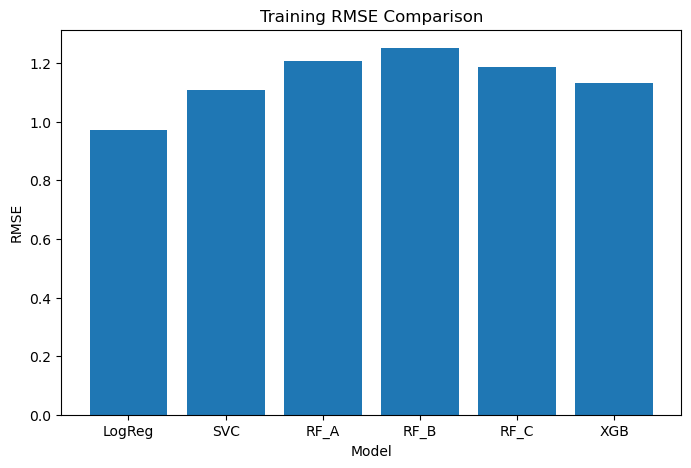

In [46]:
# training RMSE
plt.figure(figsize=(8,5))
plt.bar(models, train_rmse)

plt.title('Training RMSE Comparison')
plt.xlabel('Model')
plt.ylabel('RMSE')

plt.show()

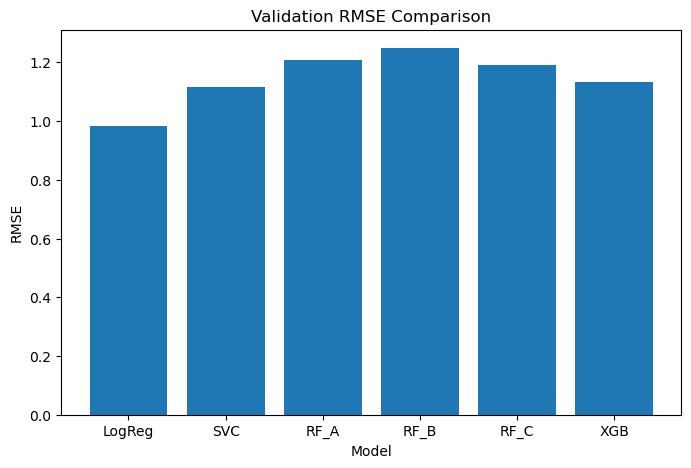

In [48]:
# validation RMSE
plt.figure(figsize=(8,5))
plt.bar(models, val_rmse)

plt.title('Validation RMSE Comparison')
plt.xlabel('Model')
plt.ylabel('RMSE')

plt.show()

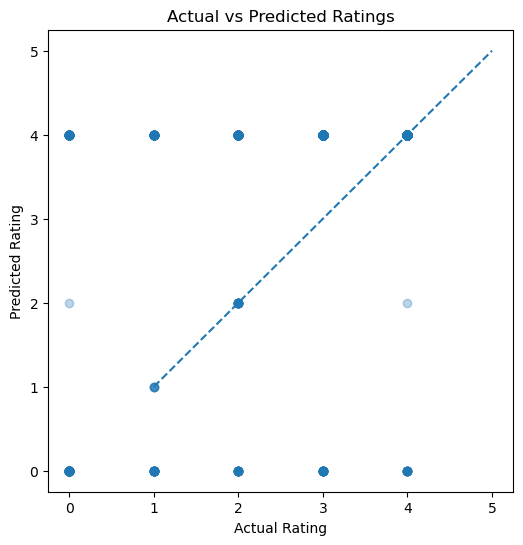

In [53]:
# Actual vs Predicted Scatter Plot
sample_df = (
    rf_val_b_pred
    .select('label', 'prediction')
    .sample(0.01)
    .toPandas()
)

plt.figure(figsize=(6,6))
plt.scatter(sample_df['label'], sample_df['prediction'], alpha=0.3)
plt.plot([1,5],[1,5], linestyle='--')

plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Ratings')

plt.show()

### Feature Importance

Feature count: 18
RF importance count: 18
                        feature  importance
12         body_sentiment_score    0.297806
13     headline_sentiment_score    0.243295
16           sentiment_x_length    0.176836
15           abs_body_sentiment    0.082161
4           review_headline_len    0.073852
14                sentiment_gap    0.055125
3            review_word_counts    0.022177
2                    review_len    0.014069
10   headline_body_length_ratio    0.009479
7              num_exclamations    0.008244
5   review_headline_word_counts    0.005521
17      sentiment_x_helpfulness    0.004643
1                  category_idx    0.004307
9                 helpful_ratio    0.001701
8                 num_uppercase    0.000308
6               avg_word_length    0.000242
11              uppercase_ratio    0.000223
0         verified_purchase_idx    0.000012


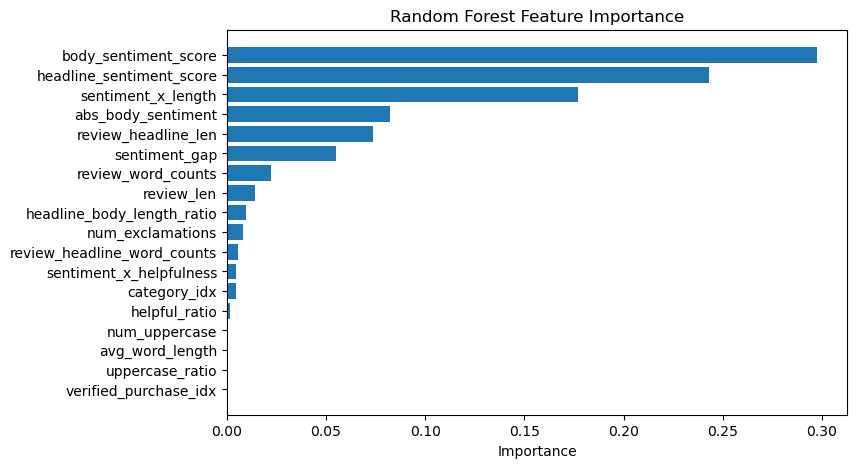

In [131]:
## Random Forest Feature Importance Plot

# Define feature importancew
importances = rf_model_b.featureImportances.toArray()

print('Feature count:', len(feature_cols))
print('RF importance count:', len(feature_cols))

# Display data
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)
print(feature_importance)

# Dislay the plot
plt.figure(figsize=(8, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()

## Milestone 4 Modeling Task - Unsupervised ML Models

### Principal Component Analysis

#### Run Dimensionality Reduction

In [57]:
start = time.time()

## pick k <= number of features
## Define PCA model
pca = PCA(
    k=9, 
    inputCol='finalized_features', 
    outputCol='pca_features'
)
models['pca'] = pca

## Fit & transform
pca, pca_train_pred, pca_test_pred = helper_fit_transform(
    'pca',
    train_final,
    train_final,
    cache=True
)

## Show Eigenvectors
pca_train_pred.select('pca_features').show(3, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|pca_features                                                                                                                                                                     |
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[-116.70299101179631,-11.282995629279123,-4.318317104338568,1.7556857800071057,-1.2080848105196567,-0.3318225822211255,0.4875946245050478,0.7830729553535514,-0.1760019929534461]|
|[-22.354905260272353,-23.61584669300928,1.4978296609354012,1.8314687453981062,-3.335990561189134,-0.16398989978407436,0.4149438135033702,0.7894751409819358,-0.03239197145500226]|
|[-48.134552480160494,-15.004759565051522,-1.2524211394636675,1.8241515922706997,0.21045701182392518

#### Analyze explained variance for PCA

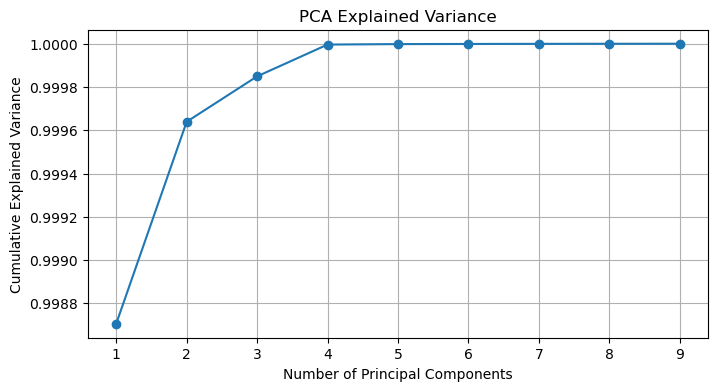

Explained variance by component:
 [9.98705818e-01 9.33511507e-04 2.09836946e-04 1.46968468e-04
 2.14890090e-06 6.66707657e-07 4.56410934e-07 3.55128940e-07
 2.38375009e-07]

Cumulative explained variance:
 [0.99870582 0.99963933 0.99984917 0.99999613 0.99999828 0.99999895
 0.99999941 0.99999976 1.        ]

ML Principal Component Analysis took: 7.00 seconds


In [58]:
## Show explained variance
# Extract explained variance
explained_variance = pca.explainedVariance.toArray()

# Plot scree plot for explained variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained_variance) + 1), np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()

# Show explained variance values
print('Explained variance by component:\n', explained_variance)
print()
print('Cumulative explained variance:\n', np.cumsum(explained_variance))
print()

elapsed = time.time() - start
print(f"ML Principal Component Analysis took: {elapsed:.2f} seconds")

**Observations**:

- Looks like we only need 1 principal component. PC1 captures the most variation in the data, which isn't really helpful because that's still 99%
- So... we're either feature redundant, or  we're feature correlated.

PCA showed that the engineered feature set had substantial redundancy. The first principal component explained about 99.8% of the total variance, and the first two to four components explained essentially all variance. This suggests the numeric features are highly correlated and can be compressed with minimal information loss.

#### Compare training vs. test performance

In [153]:
# -----------------------------
# 1. Build PCA-transformed data
# -----------------------------
start = time.time()
# Since your earlier plot showed 2-4 PCs capture nearly all variance,
# start with k=3 or k=4. We'll use k=3 here.

# Definition
pca_k = 1
pca = PCA(
    k=pca_k, 
    inputCol='finalized_features', 
    outputCol='pca_features'
)
models['pca'] = pca

## Fit & transform
pca, pca_train_pred_k_feats, pca_test_pred_k_feats = helper_fit_transform(
    'pca',
    train_final,
    val_final,
    cache=True
)

# Print explained variance info
print(f'Explained variance by {pca_k} components:', pca.explainedVariance.toArray())
print(f'Cumulative explained variance of {pca_k} components:', pca.explainedVariance.toArray().cumsum())

elapsed = time.time() - start
print(f"ML Principal Component Analysis took: {elapsed:.2f} seconds")
print('************************************************\n\n')

# ----------------------------------------
# 2. Train model on ORIGINAL feature space
# ----------------------------------------
start = time.time()
# Definition, fit & transform
rf, rf_train_pred, rf_test_pred = helper_fit_transform(
    'random_forest', 
    train_final, 
    val_final,
    cache=True
)

# Evaluation
rf_metrics = helper_evaluate_model(
    'random_forest', 
    rf_train_pred, rf_test_pred
)
rf_train_pred.unpersist()
rf_test_pred.unpersist()

elapsed = time.time() - start
print(f"ML Random Forest took: {elapsed:.2f} seconds")
print('************************************************\n\n')

# -----------------------------------
# 3. Train model on PCA feature space
# -----------------------------------
start = time.time()
# Definition
rf_pca = RandomForestClassifier(
    featuresCol='pca_features',
    labelCol='label',
    predictionCol='prediction',
    numTrees=25,
    maxDepth=8,
    maxBins=37
)
models['random_forest_pca'] = rf_pca 

# Fit & transform
rf_pca, rf_pca_train_pred, rf_pca_test_pred = helper_fit_transform(
    'random_forest_pca', 
    pca_train_pred_k_feats, 
    pca_test_pred_k_feats,
    cache=True
)
pca_train_pred_k_feats.unpersist()
pca_test_pred_k_feats.unpersist()

# Evaluation
rf_pca_metrics = helper_evaluate_model(
    'random_forest_pca', 
    rf_pca_train_pred, rf_pca_test_pred
)
rf_pca_train_pred.unpersist()
rf_pca_test_pred.unpersist()

elapsed = time.time() - start
print(f"ML Random Forest with {pca_k} principal component took: {elapsed:.2f} seconds")
print('************************************************\n\n')

# ----------------------
# 5. Collect all results
# ----------------------
def format_metrics_to_rows(model_name, metrics_dict):
    rows = []
    # Iterate metrics
    for metric, values in metrics_dict.items():
        train_val, test_val = values
        
        # initialize rows if empty
        if not rows:
            # Initialize empty rows
            rows = [
                {"model": model_name, "split": "train"},
                {"model": model_name, "split": "test"}
            ]
        # Fill up the rows
        rows[0][metric] = train_val
        rows[1][metric] = test_val
    return rows
# Apply format changes
rf_rows = format_metrics_to_rows('RF_Original', rf_metrics)
rf_pca_rows = format_metrics_to_rows('RF_PCA', rf_pca_metrics)
# Print result
pd.DataFrame(rf_rows + rf_pca_rows)

Explained variance by 1 components: [0.85801179]
Cumulative explained variance of 1 components: [0.85801179]
ML Principal Component Analysis took: 0.68 seconds
************************************************


random_forest Train f1: 0.5649
random_forest Test f1: 0.5639

random_forest Train weightedPrecision: 0.6952
random_forest Test weightedPrecision: 0.6717

random_forest Train weightedRecall: 0.6656
random_forest Test weightedRecall: 0.6643

random_forest Train accuracy: 0.6656
random_forest Test accuracy: 0.6643

ML Random Forest took: 9.60 seconds
************************************************


random_forest_pca Train f1: 0.4604
random_forest_pca Test f1: 0.4591

random_forest_pca Train weightedPrecision: 0.3703
random_forest_pca Test weightedPrecision: 0.3689

random_forest_pca Train weightedRecall: 0.6085
random_forest_pca Test weightedRecall: 0.6074

random_forest_pca Train accuracy: 0.6085
random_forest_pca Test accuracy: 0.6074

ML Random Forest with 1 principal componen

,model,split,f1,weightedPrecision,weightedRecall,accuracy
0,RF_Original,train,0.564914,0.695197,0.665576,0.665576
1,RF_Original,test,0.563895,0.671657,0.664255,0.664255
2,RF_PCA,train,0.460402,0.370280,0.608506,0.608506
3,RF_PCA,test,0.459053,0.368942,0.607406,0.607406


#### Correct classifications, false positives (FP), and false negatives (FN)

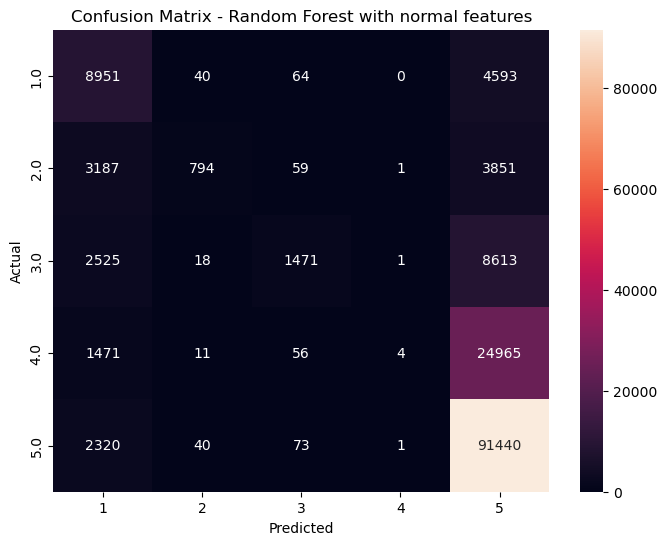

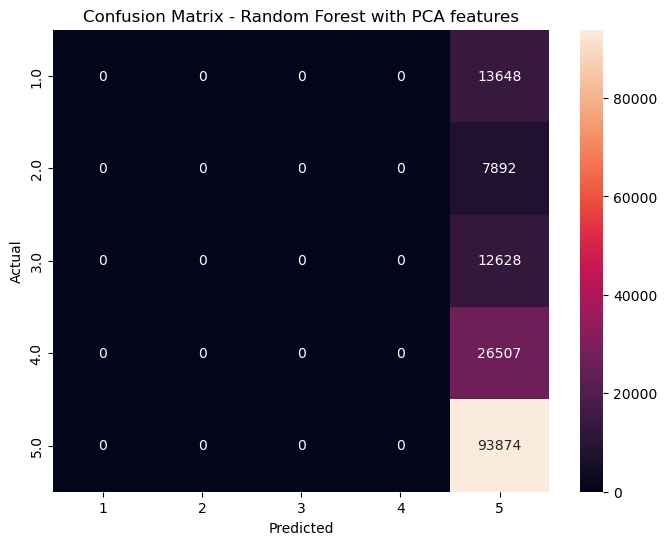

In [ ]:
def create_confusion_matrix(df, title):
    # Original labels (0-based)
    labels = [0.0, 1.0, 2.0, 3.0, 4.0]

    # Pivot to create confusion matrix
    confusion_matrix = (
        df.groupBy("label")
          .pivot("prediction", labels)
          .count()
          .fillna(0)
          .orderBy("label")
          .withColumn("label", F.col("label") + 1)  # shift labels from 0-4 → 1-5
          .toPandas()
          .set_index("label")
    )

    # Rename columns to 1-5 for display
    confusion_matrix.columns = [int(float(c))+1 for c in confusion_matrix.columns]

    # Plot
    plt.figure(figsize=(8,6))
    sns.heatmap(confusion_matrix, annot=True, fmt="g")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - Random Forest with {title} features")
    plt.show()

## Random forest with normal features
create_confusion_matrix(rf_test_pred, 'normal')

## Random forest with PCA features
create_confusion_matrix(rf_pca_test_pred, 'PCA')

**Observations**: 
- Using model with PCA features worsened the F1 and accuracy by 2%

### K-Mean Cluster

#### Run Clustering using Reduced-dimension Features

In [66]:
## Step 1: Evaluate multiple k values
# Define k vals
k_values = [2, 3, 4, 5, 6]

# Define evaluator
evaluator = ClusteringEvaluator(
    featuresCol='pca_features',
    predictionCol='prediction',
    metricName='silhouette',
    distanceMeasure='squaredEuclidean'
)

# Perform K-mean for k types
kmeans_results = []
for k in k_values:
    start = time.time()
    # Definition
    kmeans = KMeans(
        featuresCol='pca_features',
        predictionCol='prediction',
        k=k,
        seed=42
    )
    models['kmean'] = kmeans
    
    # Fit & transform
    kmean, km_train_pred, km_test_pred = helper_fit_transform(
        'kmean',
        pca_train_pred,
        pca_test_pred,
        cache=False
    )

    # Evaluate
    train_silhouette = evaluator.evaluate(km_train_pred)
    test_silhouette = evaluator.evaluate(km_test_pred)
    
    elapsed = time.time() - start
    print(f"ML K-Mean Cluster with K={k} took: {elapsed:.2f} seconds\n")

    # Store results
    kmeans_results.append({
        'k': k,
        'train_silhouette': train_silhouette,
        'test_silhouette': test_silhouette
    })

# Print result
kmeans_results_df = pd.DataFrame(kmeans_results)
print('************************************************\n\n')

print('K-Means silhouette results:')
print(kmeans_results_df.sort_values('test_silhouette', ascending=False))
print('************************************************\n\n')


## Step 2: Choose best k from validation score
best_k = int(
    kmeans_results_df
    .sort_values('test_silhouette', ascending=False)
    .iloc[0]['k']
)
print(f'Best k selected from validation silhouette: {best_k}')
print('************************************************\n\n')

## Step 3: Fit final K-Means model
# Definition
start = time.time()
kmeans_final = KMeans(
    featuresCol='pca_features',
    predictionCol='prediction',
    k=best_k,
    seed=42
)
models['kmean_final'] = kmeans_final

# Fit & transform
kmean, km_train_pred, km_test_pred = helper_fit_transform(
    'kmean_final',
    pca_train_pred,
    pca_test_pred,
    cache=False
)

# Evaluate
train_silhouette = evaluator.evaluate(km_train_pred)
test_silhouette = evaluator.evaluate(km_test_pred)

elapsed = time.time() - start
print(f"ML K-Mean Cluster Finalized took: {elapsed:.2f} seconds\n")

ML K-Mean Cluster with K=2 took: 4.34 seconds

ML K-Mean Cluster with K=3 took: 4.36 seconds

ML K-Mean Cluster with K=4 took: 4.46 seconds

ML K-Mean Cluster with K=5 took: 4.52 seconds

ML K-Mean Cluster with K=6 took: 4.59 seconds

************************************************


K-Means silhouette results:
   k  train_silhouette  test_silhouette
0  2          0.953758         0.953758
1  3          0.894368         0.894368
2  4          0.880960         0.880960
3  5          0.851462         0.851462
4  6          0.823923         0.823923
************************************************


Best k selected from validation silhouette: 2
************************************************


ML K-Mean Cluster Finalized took: 4.26 seconds



#### Evaluate clustering quality (silhouette score)

In [72]:
print(f'Train silhouette: {train_silhouette:.4f}')
print(f'Test silhouette: {test_silhouette:.4f}')
print('************************************************\n\n')

## Step 4: Final evaluation only
print(f'Best k selected from validation silhouette: {best_k}')
print(f'Train silhouette: {train_silhouette:.4f}')
print(f'Test silhouette: {test_silhouette:.4f}')
print('************************************************\n\n')

## Step 5: Cluster centers in PCA space
centers = kmean.clusterCenters()
for i, center in enumerate(centers):
    print(f'Cluster {i} center: {center}')
print('************************************************\n\n')

## Step 6: Show small sample only
(
    km_test_pred
    .select('label', 'prediction', 'pca_features')
    .show(10, truncate=False)
)

Train silhouette: 0.9538
Test silhouette: 0.9538
************************************************


Best k selected from validation silhouette: 2
Train silhouette: 0.9538
Test silhouette: 0.9538
************************************************


Cluster 0 center: [-2.60349093e+02 -2.06861271e+01 -2.48502924e+00  9.22086405e+00
  3.90247811e-02  5.42052585e-01  1.80874186e-01 -1.35005613e-02
  4.45947714e-02]
Cluster 1 center: [-2.89216634e+03 -1.73045469e+01 -2.46126975e+00  9.03934945e+00
  6.38621081e-02  4.99107545e-01  1.28820714e-01  1.20524377e-02
  6.94285836e-02]
************************************************


+-----+----------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|label|prediction|pca_features                                                                                                                                               